# 04 — Single-Variable Composite Explorer

Interactive notebook for exploring **any** variable (or sum of variables)
from the composite-blocking NPZ archive.

**Two modes**:
1. **2-panel** (default): composite mean + bootstrap significance (hatched non-sig)
2. **6-panel** (`projection=True`): adds 2×2 projection onto dh−1 orthogonal basis
   (INT, PRP, DEF, Residual) using **only significant** grid points, with
   β, αx, αy, γ in the subtitle.

Data: `/net/flood/data2/users/x_yan/composite_blocking_tempest/onset`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from functools import partial

from pvtend.plotting import (
    plot_var as _plot_var_src,
    get_field,
    load_events as _load_events_src,
    bootstrap_sig,
)

## 1  Configuration & available fields

In [2]:
DATA_ROOT  = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE      = "onset"
LEVEL      = 200 #"wavg"            # "wavg" or int hPa (e.g. 200, 250)
SMOOTH_DEG = 6.0
GRID_SP    = 1.5
N_BOOT     = 1000
ALPHA      = 0.05
SEED       = 42
PV_CONTOUR = - 0 * 0.5e-6     # PV anomaly contour for mask boundary
N_CONTOUR  = 21          # number of contourf levels

# ── Discover available fields and levels from a sample NPZ ──
_sample = np.load(f"{DATA_ROOT}/{STAGE}/dh=+0/" +
                  sorted(os.listdir(f"{DATA_ROOT}/{STAGE}/dh=+0"))[0])
levels_hpa = _sample["levels"]          # isobaric levels
wavg_levels = _sample["wavg_levels"]    # levels used for wavg

# Separate 2D (wavg) vs 3D fields
_all_keys = sorted(_sample.keys())
_meta = {"X_rel", "Y_rel", "levels", "wavg_levels", "center_lat", "center_lon",
         "center_mode", "dh", "lat0", "lat_vec", "lon0", "lon_vec_unwrapped",
         "track_id", "ts", "G0", "H_SCALE", "term"}
fields_wavg = sorted(k for k in _all_keys
                     if _sample[k].ndim == 2 and not k.endswith("_3d") and k not in _meta)
fields_3d   = sorted(k for k in _all_keys if k.endswith("_3d"))

print(f"LEVEL = {LEVEL}")
print(f"Isobaric levels (hPa): {levels_hpa}")
print(f"Wavg levels   (hPa) : {wavg_levels}")
print(f"\n── 2D wavg fields ({len(fields_wavg)}) ──")
for f in fields_wavg:
    print(f"  {f}")
print(f"\n── 3D isobaric fields ({len(fields_3d)}) ──")
for f in fields_3d[:10]:
    print(f"  {f}")
print(f"  ... ({len(fields_3d)} total)")

del _sample

LEVEL = 200
Isobaric levels (hPa): [1000  850  700  500  400  300  250  200  100]
Wavg levels   (hPa) : [300 250 200]

── 2D wavg fields (81) ──
  Q
  pv
  pv_anom
  pv_anom_dp
  pv_anom_dt
  pv_anom_dx
  pv_anom_dy
  pv_bar
  pv_bar_dp
  pv_bar_dt
  pv_bar_dx
  pv_bar_dy
  pv_dp
  pv_dx
  pv_dy
  t
  theta
  theta_dot
  theta_dt
  u
  u_anom
  u_anom_div
  u_anom_div_dry
  u_anom_div_moist
  u_anom_har
  u_anom_pv_anom_dx
  u_anom_pv_bar_dx
  u_anom_rot
  u_bar
  u_bar_pv_anom_dx
  u_bar_pv_bar_dx
  u_div_dry_pv_anom_dx
  u_div_dry_pv_bar_dx
  u_div_moist_pv_anom_dx
  u_div_moist_pv_bar_dx
  u_div_pv_anom_dx
  u_div_pv_bar_dx
  u_har_pv_anom_dx
  u_har_pv_bar_dx
  u_rot_pv_anom_dx
  u_rot_pv_bar_dx
  v
  v_anom
  v_anom_div
  v_anom_div_dry
  v_anom_div_moist
  v_anom_har
  v_anom_pv_anom_dy
  v_anom_pv_bar_dy
  v_anom_rot
  v_bar
  v_bar_pv_anom_dy
  v_bar_pv_bar_dy
  v_div_dry_pv_anom_dy
  v_div_dry_pv_bar_dy
  v_div_moist_pv_anom_dy
  v_div_moist_pv_bar_dy
  v_div_pv_anom_dy
  v_di

## 2  Bind `pvtend.plotting` to notebook config

In [3]:
# ═══════════════════════════════════════════════════════════
#  Bind notebook config to src functions — existing calls work unchanged
# ═══════════════════════════════════════════════════════════
plot_var = partial(
    _plot_var_src,
    data_root=DATA_ROOT, stage=STAGE, level=LEVEL,
    smooth_deg=SMOOTH_DEG, grid_sp=GRID_SP,
    n_boot=N_BOOT, alpha=ALPHA, seed=SEED,
    pv_contour=PV_CONTOUR, n_contour=N_CONTOUR,
)
load_events = partial(_load_events_src, data_root=DATA_ROOT, stage=STAGE)

print("plot_var / load_events bound to notebook config via pvtend.plotting")

plot_var / load_events bound to notebook config via pvtend.plotting


## 3  `plot_var` ready

In [4]:
# plot_var() now lives in pvtend.plotting.composite_explorer
# Bound to notebook config above — all example calls below work unchanged.
# Override any param per-call, e.g. plot_var(["u_bar"], dh=0, level=500)
print(f"plot_var ready — DATA_ROOT=...{DATA_ROOT[-30:]}, STAGE={STAGE}, LEVEL={LEVEL}")

plot_var ready — DATA_ROOT=...yan/composite_blocking_tempest, STAGE=onset, LEVEL=200


## 4  Examples

Computing bootstrap (N=1134, n_boot=1000) ...
  60.2% significant at 95%


/net/flood/data2/users/x_yan/pvtend/src/pvtend/plotting/composite_explorer.py:372: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


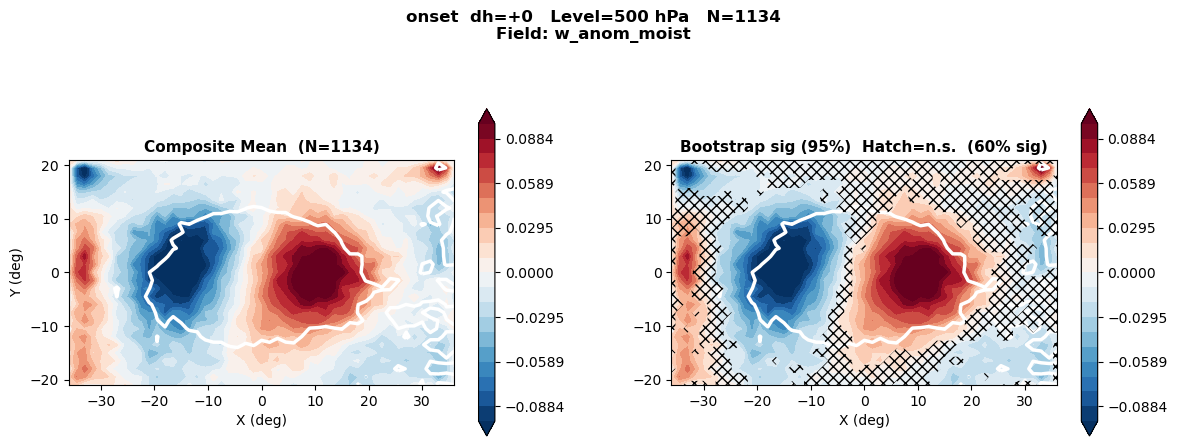

In [5]:
plot_var(["w_anom_moist"], dh=0, level=500, projection = False)

Computing bootstrap (N=1134, n_boot=1000) ...
  53.1% significant at 95%


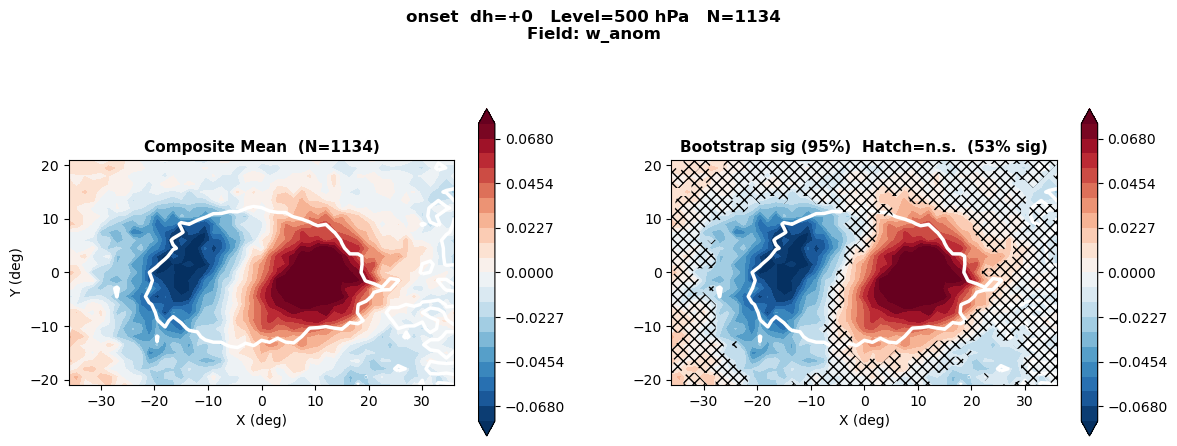

In [6]:
plot_var(["w_anom"], dh=0, level= 500, projection = False)

Computing bootstrap (N=1134, n_boot=1000) ...
  48.8% significant at 95%


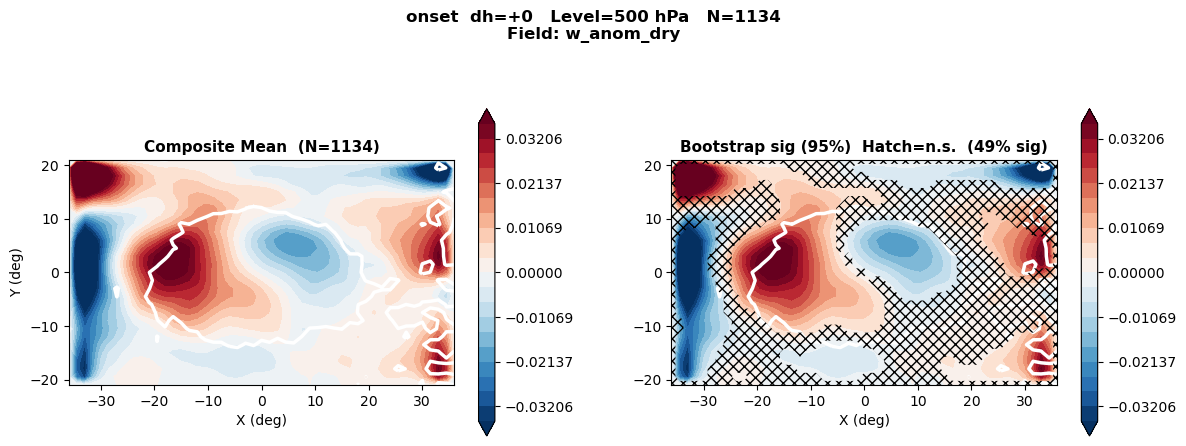

In [7]:
plot_var(["w_anom_dry"], dh=0, level=500, projection = False)

## Some horizontal wind fields

Computing bootstrap (N=1134, n_boot=1000) ...
  88.2% significant at 95%


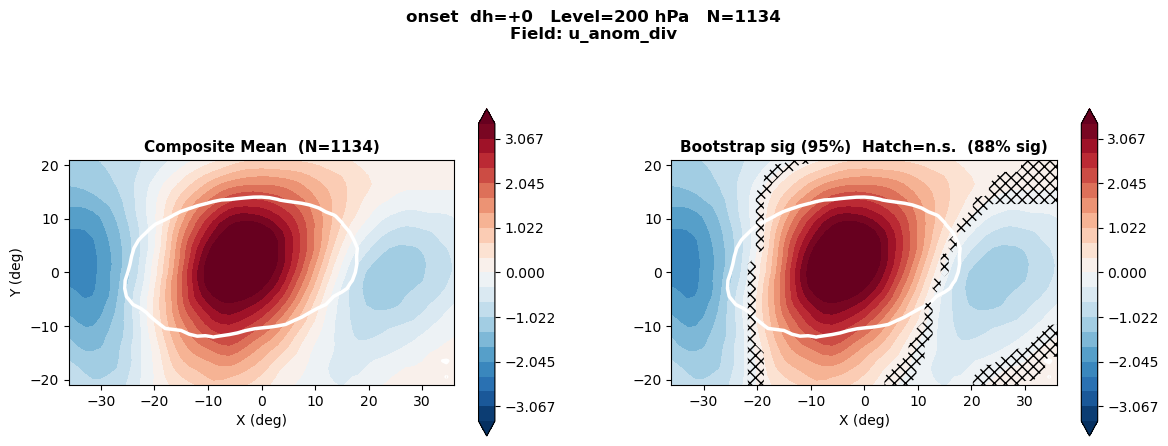

In [8]:
plot_var(["u_anom_div"], dh=0, level=200, projection = False)

Computing bootstrap (N=1134, n_boot=1000) ...
  94.4% significant at 95%


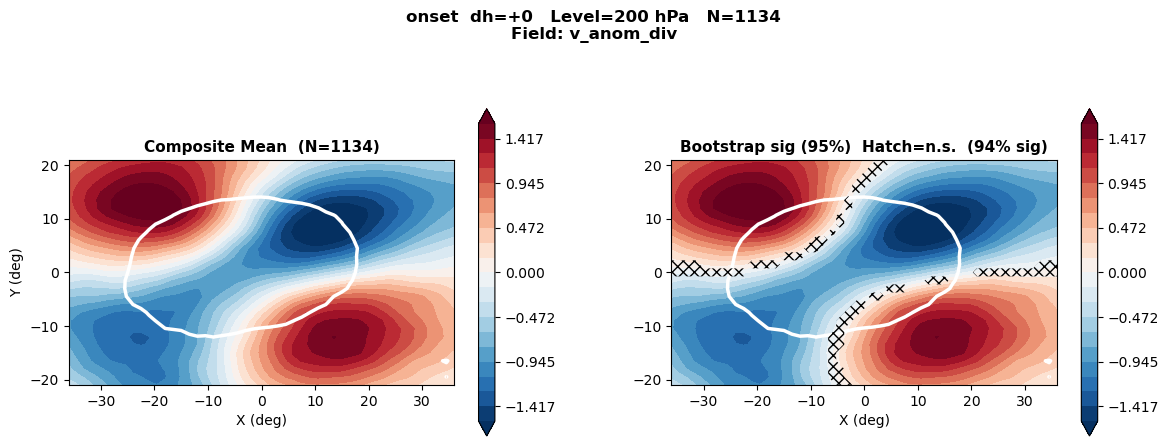

In [9]:
plot_var(["v_anom_div"], dh=0, level=200, projection = False)

Computing bootstrap (N=1134, n_boot=1000) ...
  54.9% significant at 95%


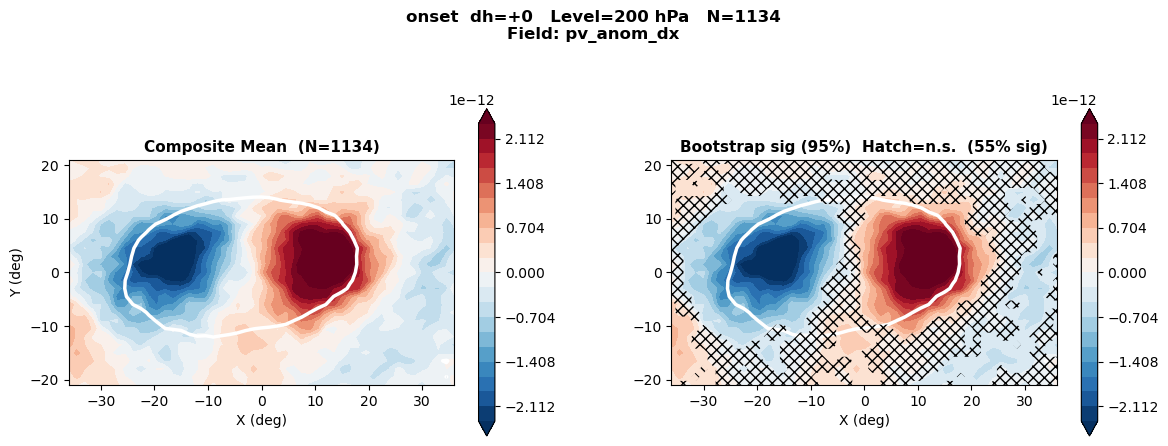

In [10]:
plot_var(["pv_anom_dx"], dh=0, level=200, projection = False)

Computing bootstrap (N=1134, n_boot=1000) ...
  58.2% significant at 95%


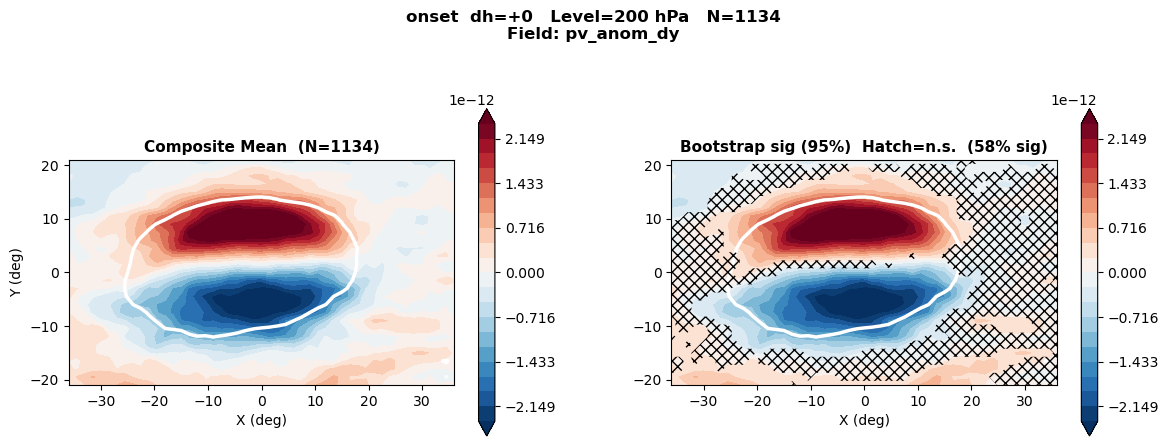

In [11]:
plot_var(["pv_anom_dy"], dh=0, level=200, projection = False)

## Tendency terms!

Computing bootstrap (N=1134, n_boot=1000) ...
  43.8% significant at 95%
  Projection (sig-only): β=1.557e-06  αx=0.737  αy=-0.527  γ=1.508e+04


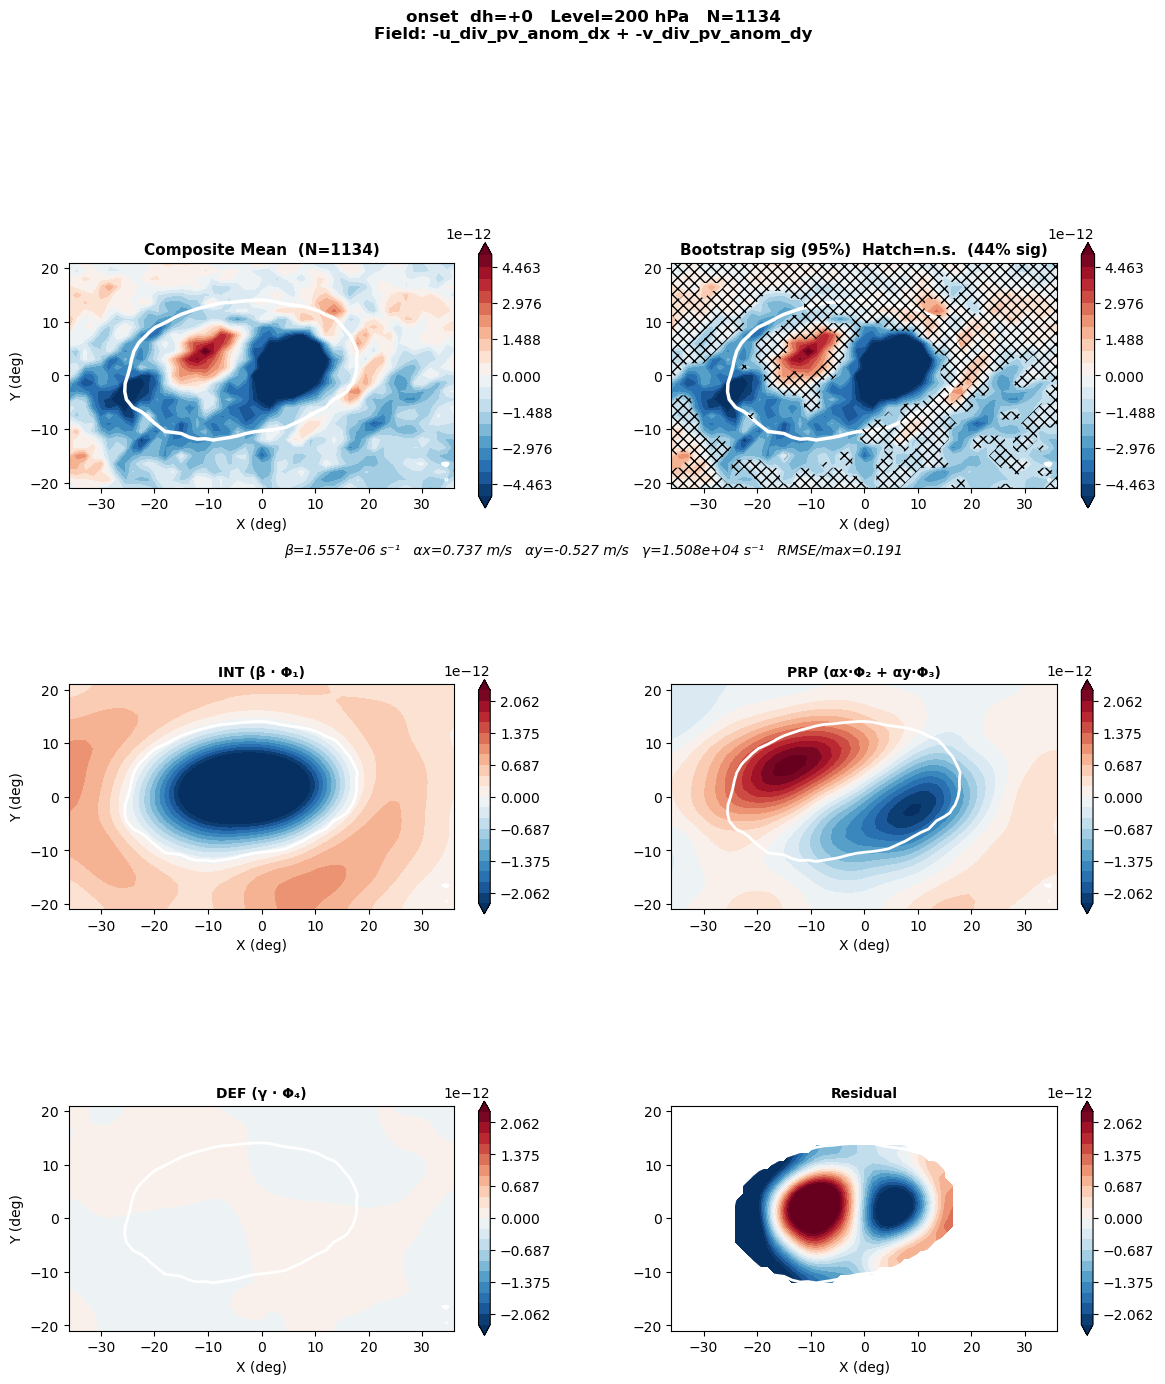

{'beta': 1.5570688522952602e-06,
 'ax': 0.7365944800990848,
 'ay': -0.526834418797771,
 'gamma': 15077.28761320752,
 'gamma_km2': 0.01507728761320752,
 'beta_raw': 1.5570688522952603e-12,
 'ax_raw': 7.365944800990848e-13,
 'ay_raw': -5.26834418797771e-13,
 'gamma_raw': 1.507728761320752e-14,
 'prop': array([[-5.47946087e-14, -2.87941852e-14,  7.06942758e-15, ...,
          8.66413202e-14,  5.06672175e-14,  2.91986874e-14],
        [-8.96491748e-14, -6.33321759e-14, -2.50322875e-14, ...,
          1.06371516e-13,  7.04219953e-14,  4.97254062e-14],
        [-1.41262809e-13, -1.14444152e-13, -7.25569075e-14, ...,
          1.48312531e-13,  1.13236471e-13,  9.40310558e-14],
        ...,
        [-3.47604215e-13, -3.53732718e-13, -3.56433322e-13, ...,
          1.29466513e-13,  1.50475858e-13,  1.60718009e-13],
        [-3.40626602e-13, -3.46658621e-13, -3.48221597e-13, ...,
          1.13142234e-13,  1.48084796e-13,  1.65630206e-13],
        [-3.41820576e-13, -3.46714619e-13, -3.45276713e-

In [12]:
# 6-panel: divergent outflow (no projection)
plot_var(["-u_div_pv_anom_dx", "-v_div_pv_anom_dy"], dh=0, level=200, projection=True)

Computing bootstrap (N=1134, n_boot=1000) ...
  12.0% significant at 95%
  Projection (sig-only): β=7.835e-07  αx=-0.139  αy=0.302  γ=-6.890e+05


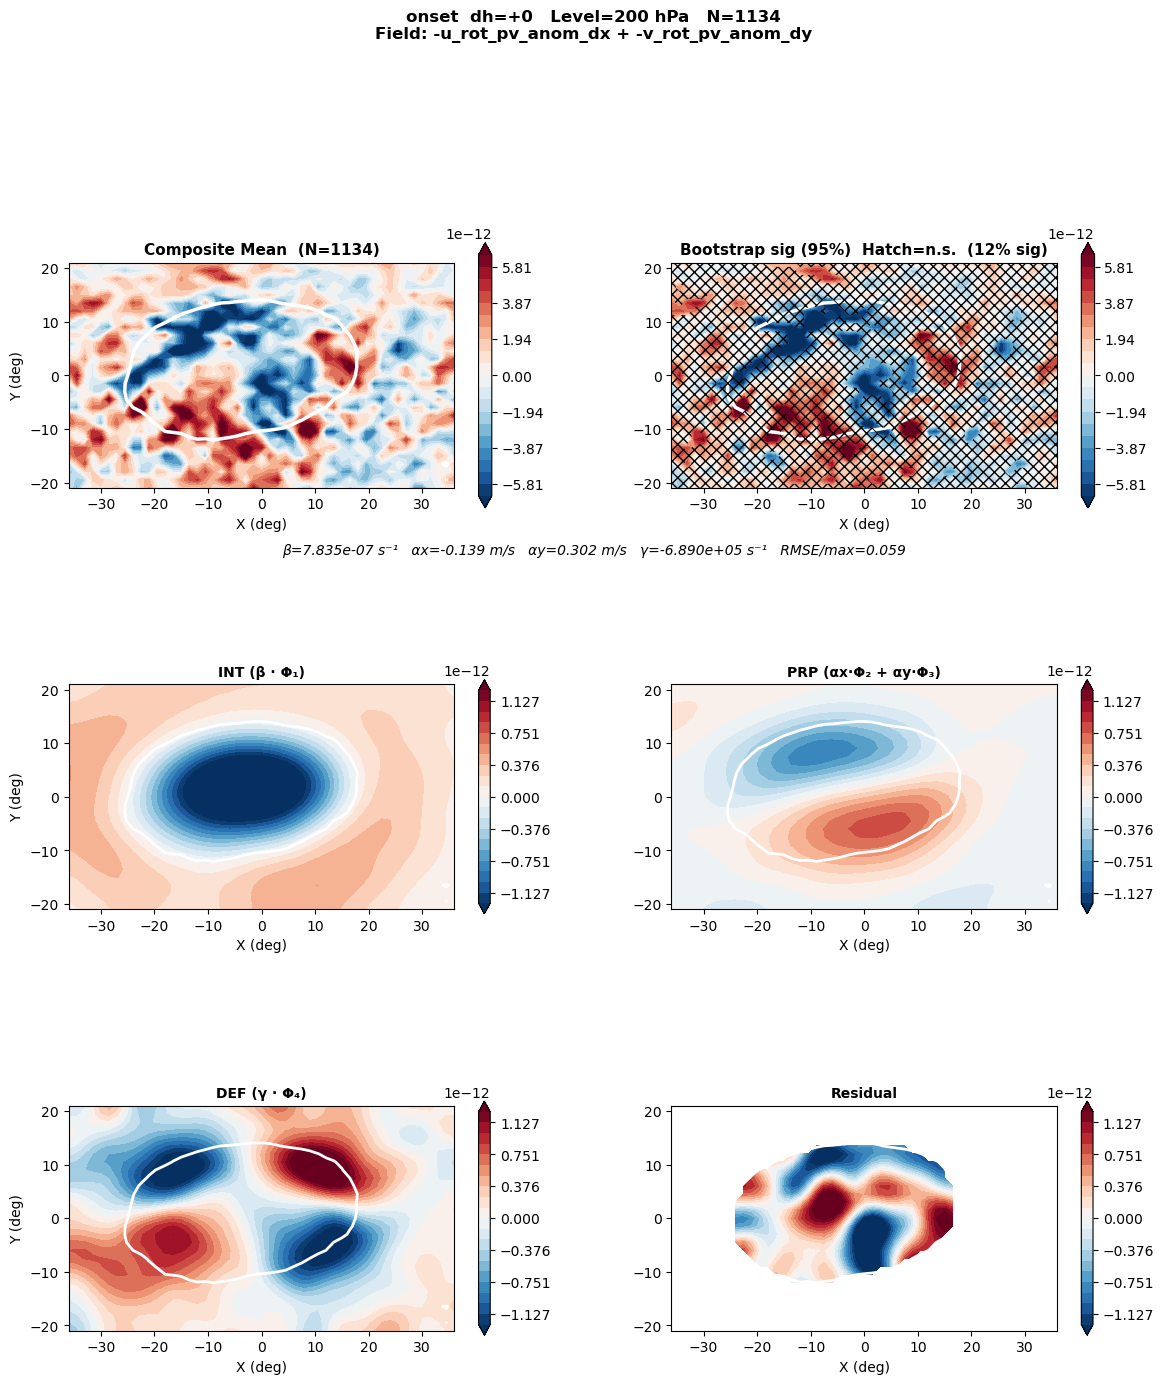

{'beta': 7.835495153077622e-07,
 'ax': -0.13901161052866995,
 'ay': 0.3021669426970833,
 'gamma': -688979.4340340572,
 'gamma_km2': -0.6889794340340571,
 'beta_raw': 7.835495153077622e-13,
 'ax_raw': -1.3901161052866995e-13,
 'ay_raw': 3.0216694269708326e-13,
 'gamma_raw': -6.889794340340572e-13,
 'prop': array([[-7.60254944e-14, -8.62210501e-14, -1.01532808e-13, ...,
         -2.01999093e-14, -1.28541795e-14, -8.44695800e-15],
        [-6.62959859e-14, -7.58280684e-14, -9.01330127e-14, ...,
         -2.78145459e-14, -1.95188047e-14, -1.46087346e-14],
        [-5.24268606e-14, -6.06086952e-14, -7.28552992e-14, ...,
         -4.38629794e-14, -3.41142966e-14, -2.83669170e-14],
        ...,
        [ 1.20974645e-13,  1.22914932e-13,  1.24714688e-13, ...,
         -6.01253186e-15, -9.16817722e-15, -1.01006662e-14],
        [ 1.14957191e-13,  1.16833010e-13,  1.18598485e-13, ...,
          1.05398646e-14,  4.93135174e-15,  2.47328004e-15],
        [ 1.12568270e-13,  1.14075623e-13,  1.15172

In [13]:
# 6-panel: rotational eddy advection
plot_var(["-u_rot_pv_anom_dx", "-v_rot_pv_anom_dy"], dh=0, level=200, projection=True)

Computing bootstrap (N=1134, n_boot=1000) ...
  26.5% significant at 95%


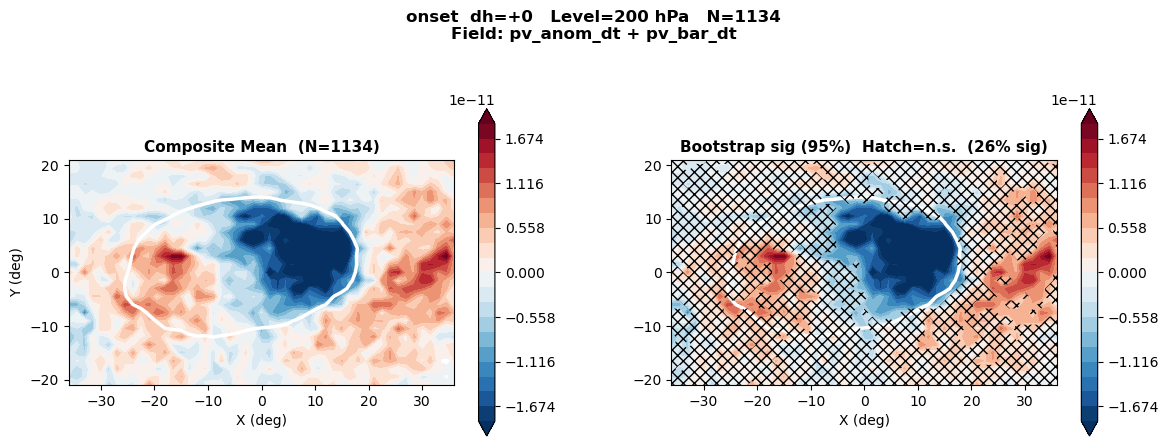

In [14]:
# 2-panel: total tendency dq/dt (no projection)
plot_var(["pv_anom_dt", "pv_bar_dt"], dh=0, level = 200, projection=False)

Computing bootstrap (N=1134, n_boot=1000) ...
  62.6% significant at 95%


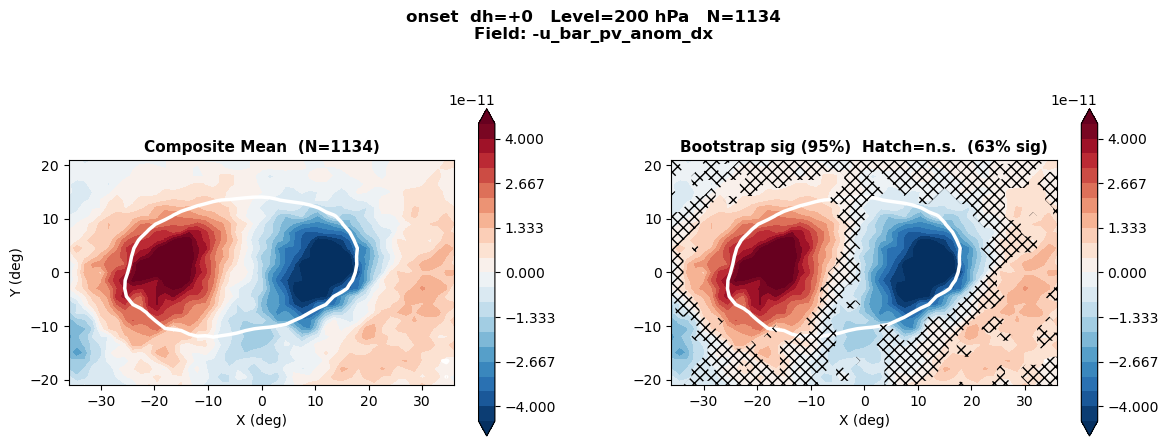

In [15]:
# 6-panel: mean-wind advection with projection
plot_var(["-u_bar_pv_anom_dx"], dh=0, level=200, projection=False)

Computing bootstrap (N=1134, n_boot=1000) ...
  81.8% significant at 95%


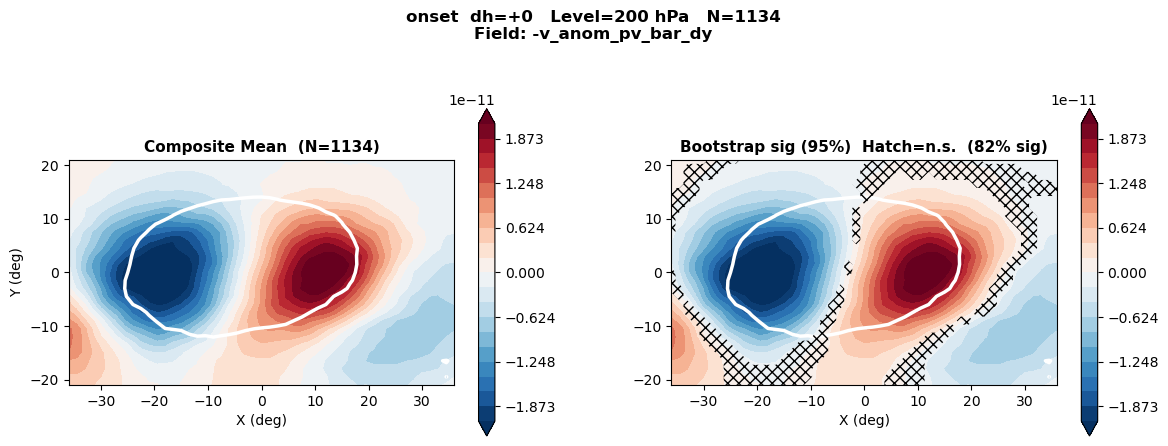

In [16]:
# 6-panel: planetary vorticity advection
plot_var(["-v_anom_pv_bar_dy"], dh=0, level=200, projection=False)

Computing bootstrap (N=1134, n_boot=1000) ...
  29.5% significant at 95%
  Projection (sig-only): β=6.134e-07  αx=-0.349  αy=-0.127  γ=-6.473e+04


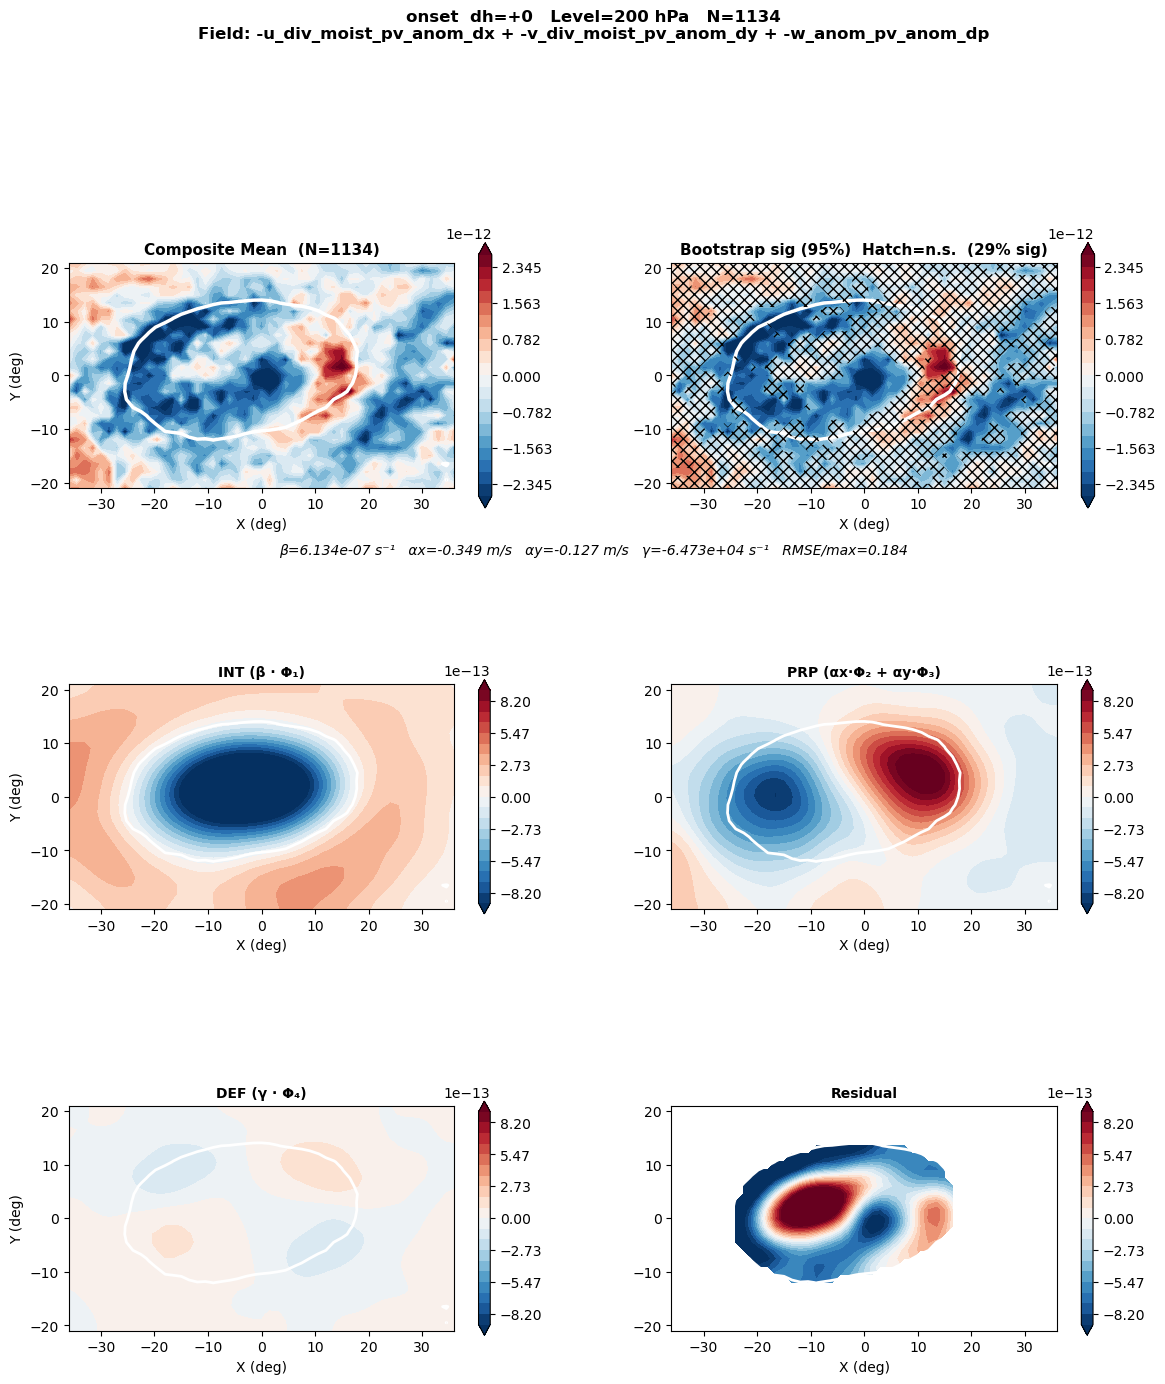

{'beta': 6.134369556343098e-07,
 'ax': -0.34851548902326485,
 'ay': -0.1272675032276826,
 'gamma': -64728.722509257495,
 'gamma_km2': -0.0647287225092575,
 'beta_raw': 6.134369556343098e-13,
 'ax_raw': -3.4851548902326484e-13,
 'ay_raw': -1.272675032276826e-13,
 'gamma_raw': -6.47287225092575e-14,
 'prop': array([[ 1.86327379e-13,  1.83847719e-13,  1.82746234e-13, ...,
         -3.38458054e-14, -1.78586372e-14, -8.36142055e-15],
        [ 1.96965244e-13,  1.92992622e-13,  1.88014640e-13, ...,
         -3.59543744e-14, -2.17518350e-14, -1.38243234e-14],
        [ 2.13718411e-13,  2.06824892e-13,  1.95069416e-13, ...,
         -4.06932997e-14, -2.99086134e-14, -2.47643664e-14],
        ...,
        [ 6.16250425e-14,  6.30691982e-14,  6.19509861e-14, ...,
         -9.54675766e-14, -1.06911042e-13, -1.13615079e-13],
        [ 6.70537260e-14,  6.85381446e-14,  6.65466005e-14, ...,
         -1.12763667e-13, -1.31127610e-13, -1.41013580e-13],
        [ 7.24738901e-14,  7.37053454e-14,  7.0483

In [17]:
# 6-panel: moist-divergent + vertical eddy-eddy
plot_var(["-u_div_moist_pv_anom_dx", "-v_div_moist_pv_anom_dy",
          "-w_anom_pv_anom_dp"], dh=0, level=200, projection=True)

Computing bootstrap (N=1134, n_boot=1000) ...
  56.6% significant at 95%
  Projection (sig-only): β=3.661e-07  αx=-0.600  αy=1.043  γ=-1.694e+04


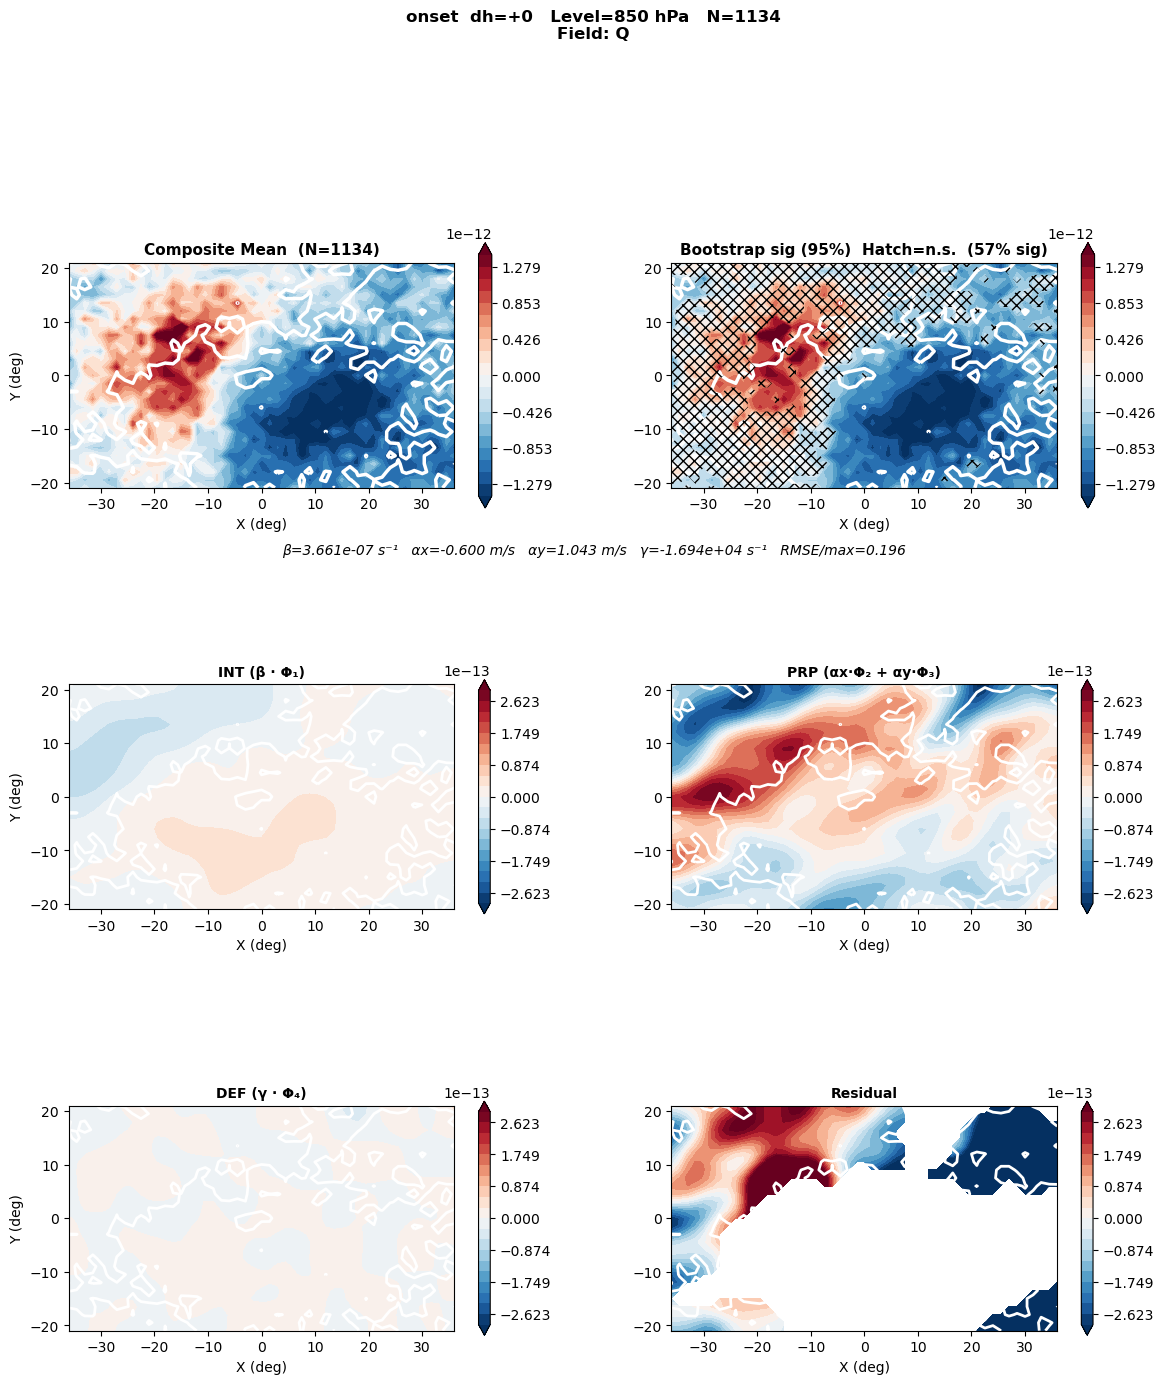

{'beta': 3.6611518358802117e-07,
 'ax': -0.5996408584202632,
 'ay': 1.0430849840632903,
 'gamma': -16935.97758466866,
 'gamma_km2': -0.016935977584668662,
 'beta_raw': 3.6611518358802116e-13,
 'ax_raw': -5.996408584202632e-13,
 'ay_raw': 1.0430849840632904e-12,
 'gamma_raw': -1.6935977584668662e-14,
 'prop': array([[-4.22349823e-14, -4.98132423e-14, -5.54731281e-14, ...,
          5.19813132e-14,  6.13056139e-14,  5.96559905e-14],
        [-5.79466708e-14, -6.66550531e-14, -7.53923084e-14, ...,
          2.73358501e-14,  4.16275844e-14,  4.25751439e-14],
        [-6.49652868e-14, -7.49443769e-14, -8.84390325e-14, ...,
         -4.40583569e-15,  1.45926080e-14,  1.96090132e-14],
        ...,
        [-7.72837167e-14, -9.73080342e-14, -1.30008344e-13, ...,
         -8.28637954e-14, -1.00304210e-13, -1.13680381e-13],
        [-7.94040635e-14, -8.79797921e-14, -1.03246040e-13, ...,
         -1.44889655e-13, -1.69009129e-13, -1.84135194e-13],
        [-9.16869522e-14, -9.32642882e-14, -9.60

In [18]:
# 6-panel: diabatic Q
plot_var(["Q"], dh=0, level=850, projection=True)

## Summary

- All helpers live in `pvtend.plotting.composite_explorer` — no inline code needed.
- **`plot_var(var_spec, dh, level, projection)`** is the main entry point.
- **`var_spec`** accepts three forms:
  1. `str` / `list[str]` with optional `-` prefix for negation (fields summed).
  2. `callable(event) → 2-D array` — full control.
- `data_root=`, `stage=`, `level=`, `dh=` are all configurable (bound via `functools.partial` above).
- `projection=True` adds a 2×2 panel showing INT/PRP/DEF/Residual from the dh−1 orthogonal basis, using **only bootstrapped-significant** grid points.
- `label=` overrides the auto-generated title label.
- White contour marks PV anomaly = 0 PVU (mask boundary).
- API docs: `pvtend.plotting.plot_var`, `pvtend.plotting.get_field`, `pvtend.plotting.bootstrap_sig`, `pvtend.plotting.load_events`